# 02 · Markov embedding and echo-corrected absorption

The mean response to a release is $C e^{\mathcal A t} z_0$ (Corollary 4). We compare the direct news kernel with the full response and check the stability theorem.

In [1]:
import os, sys
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")  # notebooks run on CPU
os.environ.setdefault("OMP_NUM_THREADS", "4")
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
import numpy as np, json, warnings
warnings.filterwarnings("ignore")

In [2]:
from infodiff.models.dictionary import PhaseTypeDictionary
from infodiff.models.statespace import StateSpaceHawkes
endo = PhaseTypeDictionary.log_grid(0.05, 5.0, 3, orders=2)
exo = PhaseTypeDictionary.log_grid(0.5, 20.0, 2, orders=3)
A = np.zeros((2, 2, endo.K, endo.R)); A[0, 0, 1, 0] = 0.5; A[1, 0, 0, 1] = 0.3; A[0, 1, 2, 0] = 0.25
W = np.zeros((2, exo.K, exo.R)); W[0, 0, 1] = 3.0
ss = StateSpaceHawkes(endo, A)
print("rho(G) =", round(ss.spectral_radius(), 3), " spectral abscissa =", round(ss.spectral_abscissa(), 4))
print("t50 direct =", round(ss.absorption_time(exo, W, 0.5, direct=True), 2), "s;  t50 echo-corrected =",
      round(ss.absorption_time(exo, W, 0.5), 2), "s;  amplification =", ss.amplification(exo, W).round(2))

rho(G) = 0.621  spectral abscissa = -0.1664
t50 direct = 0.84 s;  t50 echo-corrected = 1.46 s;  amplification = [2.35  inf]


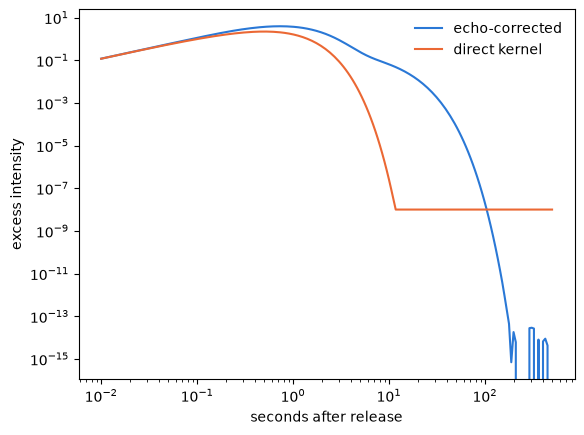

In [3]:
import matplotlib.pyplot as plt
t = np.geomspace(0.01, 500, 200)
r = ss.response_curves(exo, W, t)
plt.loglog(t, r.total.sum(1), label="echo-corrected", color="#2a78d6")
plt.loglog(t, np.maximum(r.direct.sum(1), 1e-8), label="direct kernel", color="#eb6834")
plt.xlabel("seconds after release"); plt.ylabel("excess intensity"); plt.legend(frameon=False); plt.show()